In [2]:
from dotenv import load_dotenv
import os
from langchain_openai import ChatOpenAI
from pydantic import BaseModel,Field

load_dotenv()

llm=ChatOpenAI(model="deepseek-chat",
               base_url=os.getenv("DEEPSEEK_BASE_URL"),
               api_key=os.getenv("DEEPSEEK_API_KEY"),
               temperature=0)

In [3]:
import requests
import json

def get_weather(loc):
    """
    Function to query content weather.
    "param loc: Required parameter, of type string, representing the specific city name for the weather query.
    Note that for cities in China, the corresponding English city name should be used. For example, to query the weather for Beijing,
    the loc parameter should be input as 'Beijing'.
    :return: The result of the OpenWeather API query for current weather, with the specific URL request address being: https://api.openweathermap.org/data/2.5/weather.
    The return type is a JSON-formated object after parsing, represented as a string, containing all important weather information.
    """

    # step 1 构建请求
    url=os.getenv("WEATHER_API_URL")

    # step 2 设置查询参数
    params={
        "q":loc,
        "appid":os.getenv("WEATHER_API_KEY"),
        "units":"metric",
        "lang":"zh_cn"
    }

    response=requests.get(url,params=params)

    data=response.json()
    return json.dumps(data)

In [4]:
get_weather("beijing")

'{"coord": {"lon": 116.3972, "lat": 39.9075}, "weather": [{"id": 804, "main": "Clouds", "description": "\\u9634\\uff0c\\u591a\\u4e91", "icon": "04d"}], "base": "stations", "main": {"temp": 27.94, "feels_like": 31.95, "temp_min": 27.94, "temp_max": 27.94, "pressure": 1009, "humidity": 80, "sea_level": 1009, "grnd_level": 1004}, "visibility": 10000, "wind": {"speed": 0.64, "deg": 327, "gust": 0.87}, "clouds": {"all": 99}, "dt": 1787727460, "sys": {"type": 1, "id": 9609, "country": "CN", "sunrise": 1787693776, "sunset": 1787741814}, "timezone": 28800, "id": 1816670, "name": "Beijing", "cod": 200}'

In [5]:
from sqlalchemy import create_engine, Table, Column, Integer, String, MetaData, Float
from sqlalchemy.orm import declarative_base, sessionmaker
import pymysql  # ✅ 显式导入，让 SQLAlchemy 识别

# 创建基类
Base = declarative_base()

class Weather(Base):
    __tablename__ = 'weather'
    city_id = Column(Integer, primary_key=True)
    city_name = Column(String(50))
    main_weather = Column(String(50))
    description = Column(String(100))
    temperature = Column(Float)
    feels_like=Column(Float)
    temp_min=Column(Float)
    temp_max=Column(Float)

# ✅ mysql:// → mysql+pymysql://，用 PyMySQL 驱动
DATABASE_URI = os.getenv("DATABASE_URI")
engine = create_engine(DATABASE_URI, echo=True)

Base.metadata.create_all(engine)

Session = sessionmaker(bind=engine)
session = Session()

2026-08-26 15:06:43,072 INFO sqlalchemy.engine.Engine SELECT DATABASE()
2026-08-26 15:06:43,073 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-08-26 15:06:43,076 INFO sqlalchemy.engine.Engine SELECT @@sql_mode
2026-08-26 15:06:43,077 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-08-26 15:06:43,079 INFO sqlalchemy.engine.Engine SELECT @@lower_case_table_names
2026-08-26 15:06:43,080 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-08-26 15:06:43,082 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-08-26 15:06:43,083 INFO sqlalchemy.engine.Engine DESCRIBE `langgraph`.`weather`
2026-08-26 15:06:43,084 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-08-26 15:06:43,101 INFO sqlalchemy.engine.Engine COMMIT


In [6]:
from typing import Optional
from langchain_core.tools import tool
import requests ,json

class WeatherLoc(BaseModel):
    location:str=Field(description="the location to get the weather")

class WeatherInfo(BaseModel):
    """Extracted weather information for a city"""
    city_id:str=Field(...,description="The unique identifier for the city")
    city_name:Optional[str]=Field(description="name of the city")
    main_weather:str=Field(description="main weather condition")
    description:Optional[str]=Field(description="a detailed description of the weather")
    temperature:Optional[str]=Field(description="current temperature of the city")
    feels_like:Optional[str]=Field(description="feels-like temperature of the city")
    temp_min:Optional[str]=Field(description="minimum temperature of the city")
    temp_max:Optional[str]=Field(description="maximum temperature of the city")

@tool(args_schema=WeatherLoc)
def get_weather(location):
    """
    
    从 OpenWeather API 实时查询天气。仅在数据库中查询不到该城市天气时使用。
    优先使用 query_weather_from_db 工具。
    
    Function to query content weather.
    "param location: Required parameter, of type string, representing the specific city name for the weather query.
    Note that for cities in China, the corresponding English city name should be used. For example, to query the weather for Beijing,
    the location parameter should be input as 'Beijing'.
    :return: The result of the OpenWeather API query for current weather, with the specific URL request address being: https://api.openweathermap.org/data/2.5/weather.
    The return type is a JSON-formated object after parsing, represented as a string, containing all important weather information.
    
    """
    # step 1 构建请求
    url=os.getenv("WEATHER_API_URL")
    # step 2 设置查询参数
    params={
        "q":location,
        "appid":os.getenv("WEATHER_API_KEY"),
        "units":"metric",
        "lang":"zh_cn"
    }
    response=requests.get(url,params=params)
    data=response.json()
    return json.dumps(data)

@tool(args_schema=WeatherInfo)
def insert_weather_to_db(city_id,city_name,main_weather,description,temperature,feels_like,temp_min,temp_max):
    """insert weather information into the database"""
    session=Session()
    try:
        weather=Weather(city_id=city_id,city_name=city_name,main_weather=main_weather,
                        description=description,temperature=temperature,feels_like=feels_like,temp_min=temp_min,temp_max=temp_max)
        session.merge(weather)
        session.commit()
        return {"messages":[f"天气数据已成功存储到db"]}
    except Exception as e:
        session.rollback()
        return {"messages":[f"天气数据保存失败，错误是{e}"]}
    finally:
        session.close()
        
class QueryWeatherSchema(BaseModel):
    """Schema for querying weather information by city name"""
    city_name: str=Field(..., description="The name of the city to query weather information")

@tool(args_schema=QueryWeatherSchema)
def query_weather_from_db(city_name):
    """query weather information from db by city name"""
    session=Session()
    try:
        weather_data=session.query(Weather).filter(Weather.city_name==city_name).first()
        if weather_data:
            return {
                "city_id":weather_data.city_id,
                "city_name":weather_data.city_name,
                "main_weather":weather_data.main_weather,
                "description":weather_data.description,
                "temperature":weather_data.temperature,
                "feels_like":weather_data.feels_like,
                "temp_min":weather_data.temp_min,
                "temp_max":weather_data.temp_max
            }
        else:
            return {"messages":[f"未找到城市 {city_name} 的天气信息"]}
    except Exception as e:
        return {"messages":[f"查询失败，错误原因, {e}"]}
    finally:
        session.close()

In [7]:
result=query_weather_from_db.invoke({"city_name":"beijing"})
result

2026-08-26 15:06:43,262 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-08-26 15:06:43,266 INFO sqlalchemy.engine.Engine SELECT weather.city_id AS weather_city_id, weather.city_name AS weather_city_name, weather.main_weather AS weather_main_weather, weather.description AS weather_description, weather.temperature AS weather_temperature, weather.feels_like AS weather_feels_like, weather.temp_min AS weather_temp_min, weather.temp_max AS weather_temp_max 
FROM weather 
WHERE weather.city_name = %(city_name_1)s 
 LIMIT %(param_1)s
2026-08-26 15:06:43,268 INFO sqlalchemy.engine.Engine [generated in 0.00130s] {'city_name_1': 'beijing', 'param_1': 1}
2026-08-26 15:06:43,271 INFO sqlalchemy.engine.Engine ROLLBACK


{'city_id': 1816670,
 'city_name': 'Beijing',
 'main_weather': 'Clouds',
 'description': '阴，多云',
 'temperature': 27.94,
 'feels_like': 31.09,
 'temp_min': 27.94,
 'temp_max': 27.94}

In [8]:
class SearchQuery(BaseModel):
    """the query to fetch real time infor"""
    query: str = Field(description="the query to fetch real time infor")


@tool(args_schema=SearchQuery)
def fetch_real_time_info(query):
    """fetch real time info from internet"""
    print("--------------")
    url = os.getenv("BAIDU_API_URL")

    payload = json.dumps(
        {
            "messages": [{"role": "user", "content": query}],
            "edition": "standard",
            "search_source": "baidu_search_v2",
            "search_recency_filter": "week",
        },
        ensure_ascii=False,
    )
    headers = {
        "Content-Type": "application/json",
        "Authorization": "Bearer " + os.getenv("BAIDU_API_KEY"),
    }

    response = requests.request(
        "POST", url, headers=headers, data=payload.encode("utf-8")
    )

    response.encoding = "utf-8"
    print(response.text)

    response = requests.get(url)
    result = json.loads(response.text)
    return result

In [9]:
tools=[fetch_real_time_info,get_weather,insert_weather_to_db,query_weather_from_db]
tools

[StructuredTool(name='fetch_real_time_info', description='fetch real time info from internet', args_schema=<class '__main__.SearchQuery'>, func=<function fetch_real_time_info at 0x0000025638CE4E00>),
 StructuredTool(name='get_weather', description='从 OpenWeather API 实时查询天气。仅在数据库中查询不到该城市天气时使用。\n优先使用 query_weather_from_db 工具。\n\nFunction to query content weather.\n"param location: Required parameter, of type string, representing the specific city name for the weather query.\nNote that for cities in China, the corresponding English city name should be used. For example, to query the weather for Beijing,\nthe location parameter should be input as \'Beijing\'.\n:return: The result of the OpenWeather API query for current weather, with the specific URL request address being: https://api.openweathermap.org/data/2.5/weather.\nThe return type is a JSON-formated object after parsing, represented as a string, containing all important weather information.', args_schema=<class '__main__.WeatherLoc'

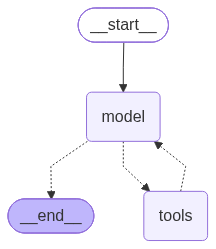

In [10]:
from langchain.agents import create_agent

graph=create_agent(llm,tools)
graph

In [11]:
from langchain_core.messages import HumanMessage,AIMessageChunk

first=True
async for msg,metadata in graph.astream({"messages":["你好，帮我查询一下数据库中的沈阳的天气数据"]},stream_mode="messages"):
    if msg.content and not isinstance(msg,HumanMessage):
        print(msg.content,end="|",flush=True)
        
        if isinstance(msg,AIMessageChunk):
            if first:
                gathered=msg
                first=False
            else:
                gathered=gathered+msg
                
            if msg.tool_call_chunks:
                print(gathered.tool_calls)

我来|帮|您|查询|数据库中|沈阳|的|天气|数据|。|2026-08-26 15:06:45,971 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-08-26 15:06:45,984 INFO sqlalchemy.engine.Engine SELECT weather.city_id AS weather_city_id, weather.city_name AS weather_city_name, weather.main_weather AS weather_main_weather, weather.description AS weather_description, weather.temperature AS weather_temperature, weather.feels_like AS weather_feels_like, weather.temp_min AS weather_temp_min, weather.temp_max AS weather_temp_max 
FROM weather 
WHERE weather.city_name = %(city_name_1)s 
 LIMIT %(param_1)s
2026-08-26 15:06:45,985 INFO sqlalchemy.engine.Engine [cached since 2.718s ago] {'city_name_1': '沈阳', 'param_1': 1}
2026-08-26 15:06:45,987 INFO sqlalchemy.engine.Engine ROLLBACK
{"city_id": 2034937, "city_name": "沈阳", "main_weather": "Clear", "description": "晴", "temperature": 28.01, "feels_like": 30.55, "temp_min": 28.01, "temp_max": 28.01}|我已经|从|数据库中|查询|到了|沈阳|的|天气|数据|，|以下是|详细信息|：

|###| 🌤|️| |沈阳|天气|数据|

||| |项目| || |数据| |
|||----

In [12]:
async for event in graph.astream_events({'messages':['你好，请你介绍一下你自己']},version='v2'):
    eventType=event['event']
    print(f"{eventType}:{event['name']}")

on_chain_start:LangGraph
on_chain_start:model
on_chat_model_start:ChatOpenAI
on_chat_model_stream:ChatOpenAI
on_chat_model_stream:ChatOpenAI
on_chat_model_stream:ChatOpenAI
on_chat_model_stream:ChatOpenAI
on_chat_model_stream:ChatOpenAI
on_chat_model_stream:ChatOpenAI
on_chat_model_stream:ChatOpenAI
on_chat_model_stream:ChatOpenAI
on_chat_model_stream:ChatOpenAI
on_chat_model_stream:ChatOpenAI
on_chat_model_stream:ChatOpenAI
on_chat_model_stream:ChatOpenAI
on_chat_model_stream:ChatOpenAI
on_chat_model_stream:ChatOpenAI
on_chat_model_stream:ChatOpenAI
on_chat_model_stream:ChatOpenAI
on_chat_model_stream:ChatOpenAI
on_chat_model_stream:ChatOpenAI
on_chat_model_stream:ChatOpenAI
on_chat_model_stream:ChatOpenAI
on_chat_model_stream:ChatOpenAI
on_chat_model_stream:ChatOpenAI
on_chat_model_stream:ChatOpenAI
on_chat_model_stream:ChatOpenAI
on_chat_model_stream:ChatOpenAI
on_chat_model_stream:ChatOpenAI
on_chat_model_stream:ChatOpenAI
on_chat_model_stream:ChatOpenAI
on_chat_model_stream:ChatOp

In [19]:
events=[]
async for event in graph.astream_events({'messages':['你好，请你介绍一下你自己']},version="v2"):
    events.append(event)
    print(event)
    
events[0]

{'event': 'on_chain_start', 'data': {'input': {'messages': ['你好，请你介绍一下你自己']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '01a03ce7-f479-7d31-a595-ae07c035291e', 'metadata': {'ls_integration': 'langchain_create_agent'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='你好，请你介绍一下你自己', additional_kwargs={}, response_metadata={}, id='5d5f5e04-5149-4555-b542-e4a0f0de189f')]}}, 'name': 'model', 'tags': ['graph:step:1'], 'run_id': '01a03ce7-f47f-7c22-9490-8e2906ccd8f5', 'metadata': {'ls_integration': 'langchain_create_agent', 'langgraph_step': 1, 'langgraph_node': 'model', 'langgraph_triggers': ('branch:to:model',), 'langgraph_path': ('__pregel_pull', 'model'), 'langgraph_checkpoint_ns': 'model:2e4c480d-9dd0-495d-a414-878b81022ac8'}, 'parent_ids': ['01a03ce7-f479-7d31-a595-ae07c035291e']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[HumanMessage(content='你好，请你介绍一下你自己', additional_kwargs={}, response_metadata={}, id='5d5f5

{'event': 'on_chain_start',
 'data': {'input': {'messages': ['你好，请你介绍一下你自己']}},
 'name': 'LangGraph',
 'tags': [],
 'run_id': '01a03ce7-f479-7d31-a595-ae07c035291e',
 'metadata': {'ls_integration': 'langchain_create_agent',
  'LANGSMITH_ENDPOINT': 'https://api.smith.langchain.com',
  'LANGSMITH_PROJECT': 'chat',
  'LANGSMITH_TRACING': 'true',
  'revision_id': '575d285'},
 'parent_ids': []}

In [18]:
print((len(events)))

158


In [24]:
async for event in graph.astream_events({'messages':["你好，请介绍一下你自己"]},version="v2"):
    if event['event'] == 'on_chat_model_stream':
        print(event['data']['chunk'].content, end="", flush=True)

你好！我是你的智能助手，可以帮你完成各种任务。我具备以下能力：

1. **实时信息查询** - 我可以从互联网获取最新的实时信息，帮助你了解新闻、事件、数据等。

2. **天气查询** - 我可以查询全球各城市的实时天气情况，包括温度、天气状况、体感温度等详细信息。

3. **数据库管理** - 我可以将天气信息存入数据库，也可以从数据库中查询已存储的天气数据。

我的工作方式很简单：
- 你可以直接向我提问或提出需求
- 我会根据你的需求调用相应的工具来完成任务
- 然后为你提供准确、有用的回答

比如，你可以问我：
- "北京今天天气怎么样？"
- "帮我查一下最新的科技新闻"
- "查询一下上海的气温"

有什么我可以帮你的吗？😊